<a href="https://colab.research.google.com/github/dcthyun0308/ESAA/blob/main/ESAA_OB_week09_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#5.2 합성곱 신경망 맛보기

- fashion_mnist 데이터셋을 사용하여 합성곱 신경망을 직접 구현해보자.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms # 데이터 전처리를 위해 사용하는 라이브러리
from torch.utils.data import Dataset, DataLoader

파이토치는 기본적으로 GPU 사용을 권장함. 하지만 GPU가 장착되지 않은 환경에서도 파이토치를 정상적으로 실행하고 사용할 수 있음. GPU가 장착되어 있고, GPU를 사용하기 위한 설정이 되어 있다면 파이토치에서 자동으로 인식함. 하지만 책에서는 아직 GPU를 설정하기 않았기 때문에 CPU를 사용할 것.

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

이번 예제에서 사용할 fashion_mnist 데이터셋은 초티비전으로 내려받을 수 있음.

In [3]:
train_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True,
                                                  transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True,
                                                 train=False, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 292kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.0MB/s]


내려받은 fashion_mnist 데이터를 메모리로 불러오기 위해 데이터로더에 전달하자.

In [4]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

이제 예제에서 다루고 있는 이미지를 살펴보자.

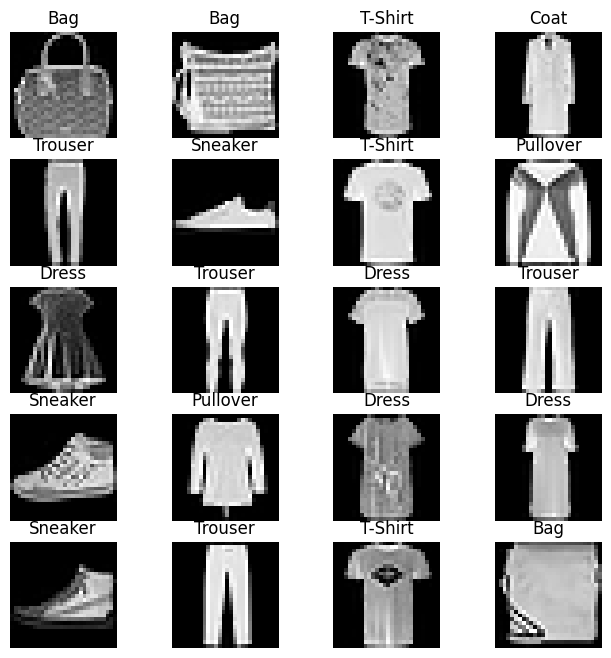

In [5]:
labels_map = {0 : 'T-Shirt', 1 : 'Trouser', 2 : 'Pullover', 3 : 'Dress', 4: 'Coat',
              5 : 'Sandal', 6 : 'Shirt', 7 : 'Sneaker' , 8 : 'Bag', 9 : 'Ankle Boot'} # 열 개의 클래스
fig = plt.figure(figsize=(8,8)); # 출력할 이미지의 가로세로 길이로 단위는 inch
columns=4;
rows=5;
for i in range(1,columns*rows+1):
    img_xy = np.random.randint(len(train_dataset));
    img = train_dataset[img_xy][0][0,:,:]
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show() # 20개의 이미지 데이터를 시각적으로 표현

합성곱 신경망과 합성곱 신경망이 아닌 심층 신경망의 비교를 위해 먼저 심층 신경망을 생성한 후 학습시켜보자. 즉, ConvNet이 적용되지 않은 네트워크를 먼저 만들어 보자.

In [6]:
class FashionDNN(nn.Module):
  def __init__(self):
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784, out_features=256)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)

  def forward(self, input_data):
    out = input_data.view(-1, 784)
    out = F.relu(self.fc1(out))
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

함수란 하나의 특정 작업을 수행하기 위해 독립적으로 설계된 프로그램 코드. 클래스는 함수뿐만 아니라 관련된 변수까지도 한꺼번에 묶어서 관리하고 재사용할 수 있게 해 주는 것.

다음으로 모델을 학습시키기 전에 손실 함수, 학습률, 옵티마이저에 대해 정의하자.

In [7]:
learning_rate=0.001;
model=FashionDNN();
model.to(device)

criterion=nn.CrossEntropyLoss(); # 분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


심층 신경망에 데이터를 적용하여 모델을 학습시키자.

In [8]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count%50):
          total=0
          correct=0
          for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels_list.append(labels)
            test = Variable(images.view(100, 1, 28, 28))
            outputs = model(test)
            predictions = torch.max(outputs, 1)[1].to(device)
            predictions_list.append(predictions)
            correct += (predictions == labels).sum()
            total += len(labels)

          accuracy = correct*100/total
          loss_list.append(loss.data)
          iteration_list.append(count)
          accuracy_list.append(accuracy)
        if not (count%500):
          print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.6156456470489502, Accuracy: 83.11000061035156%
Iteration: 1000, Loss: 0.44543594121932983, Accuracy: 83.94000244140625%
Iteration: 1500, Loss: 0.37972962856292725, Accuracy: 84.05999755859375%
Iteration: 2000, Loss: 0.3754412829875946, Accuracy: 85.5999984741211%
Iteration: 2500, Loss: 0.2810572385787964, Accuracy: 85.80000305175781%
Iteration: 3000, Loss: 0.28120478987693787, Accuracy: 86.63999938964844%


분류 문제에서 클래스가 세 개 이상일 때는 다음과 같은 사항에 주의해야 함.
- 정확도가 80% 이상이라면 80%라는 값이 모든 클래스가 동등하게 고려된 것인지, 특정 클래스의 분류가 높았던 것인지에 대해 알 수 없음에 유의해야 함.
- 정확도가 90% 이상이라면 100개의 데이터 중 90개가 하나의 클래스에 속할 경우 90%의 정확도는 높다고 할 수 없다. 즉, 모든 데이터를 특정 클래스에 속한다고 예측해도 90%의 예측 결과가 나오기 때문에 데이터 특성에 따라 정확도를 잘 관측해야 함.

합성곱 신경망을 생성해보자.

In [9]:
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
    self.drop = nn.Dropout2d(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)
  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1)
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

합성곱 네트워크를 사용하기 위한 파라미터를 정의하자.

In [10]:
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


학습 데이터를 이용하여 모델을 학습시키자.

In [11]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count%50):
          total=0
          correct=0
          for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            labels_list.append(labels)
            test = Variable(images.view(100, 1, 28, 28))
            outputs = model(test)
            predictions = torch.max(outputs, 1)[1].to(device)
            predictions_list.append(predictions)
            correct += (predictions == labels).sum()
            total += len(labels)

          accuracy = correct*100/total
          loss_list.append(loss.data)
          iteration_list.append(count)
          accuracy_list.append(accuracy)
        if not (count%500):
          print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration: 500, Loss: 0.43380728363990784, Accuracy: 87.9000015258789%
Iteration: 1000, Loss: 0.2895703613758087, Accuracy: 87.95999908447266%
Iteration: 1500, Loss: 0.29586926102638245, Accuracy: 88.05000305175781%
Iteration: 2000, Loss: 0.19920974969863892, Accuracy: 89.54000091552734%
Iteration: 2500, Loss: 0.13042764365673065, Accuracy: 89.62999725341797%
Iteration: 3000, Loss: 0.15841108560562134, Accuracy: 90.26000213623047%


심층 신경망과 비교하여 정확도가 약간 높음. 심층 신경망과 별 차이가 없기 때문에 좀 더 간편한 심층 신경망만 사용해도 무난할 것 같지만 실제로 이미지 데이터가 많아지면 단순 심층 신경망으로는 정확한 특성 추출 및 분류가 불가능하므로 합성곱 신경망을 생성할 수 있도록 학습해야 함.